Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Problem:** the fruit basket is the data. *n* random samples are taken from the basket and an individual decision tree is built for each sample. Each tree gives its own output for a new fruit (the *instance*), and **majority voting** over all trees gives the final class. Which fruit is likely to be taken most often?

**Dataset:** a synthetic fruit basket with the weight, diameter, length, sweetness and colour of each fruit.

In [2]:
basket = pd.read_csv('08-rf-dataset-task-1.csv')

In [3]:
basket.head()

,Weight_g,Diameter_cm,Length_cm,Sweetness,Colour,Fruit
0,2.2,2.1,2.4,7.1,Green,Grapes
1,4.8,1.9,2.8,6.9,Green,Grapes
2,160.7,7.8,8.6,5.7,Green,Apple
3,224.2,8.5,8.7,6.8,Red,Apple
4,2.6,1.9,2.2,7.4,Purple,Grapes


In [4]:
basket.shape

(450, 6)

Fruits in the basket
---------------------------
Fruit
Apple     150
Banana     90
Orange     80
Grapes     70
Mango      60
Name: count, dtype: int64


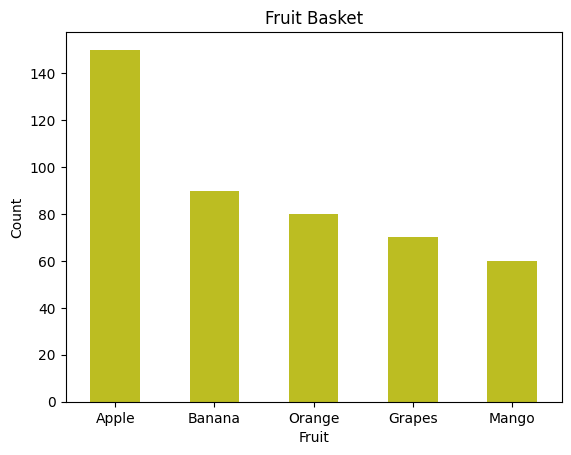

In [5]:
counts = basket['Fruit'].value_counts()
print("Fruits in the basket")
print("---------------------------")
print(counts)
counts.plot.bar(color='tab:olive', title='Fruit Basket', ylabel='Count', rot=0)
plt.show()

Colour is a text feature, so it is one-hot encoded.

In [6]:
X = pd.get_dummies(basket.drop(columns='Fruit'), columns=['Colour'], dtype=int)
y = basket['Fruit']
X.head()

,Weight_g,Diameter_cm,Length_cm,Sweetness,Colour_Green,Colour_Orange,Colour_Purple,Colour_Red,Colour_Yellow
0,2.2,2.1,2.4,7.1,1,0,0,0,0
1,4.8,1.9,2.8,6.9,1,0,0,0,0
2,160.7,7.8,8.6,5.7,1,0,0,0,0
3,224.2,8.5,8.7,6.8,0,0,0,1,0
4,2.6,1.9,2.2,7.4,0,0,1,0,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Building the forest by hand (as in the figure)

Each tree gets a **bootstrap sample**: fruits drawn at random *with replacement* from the basket, the same size as the training set. Each tree also considers only a random subset of features at each split (`max_features='sqrt'`), so the trees differ from each other.

In [8]:
n_trees = 25
rng = np.random.default_rng(42)
trees, samples = [], []
for i in range(n_trees):
    idx = rng.integers(0, len(X_train), len(X_train))   # sample with replacement
    tree = DecisionTreeClassifier(max_features='sqrt', random_state=i)
    tree.fit(X_train.iloc[idx], y_train.iloc[idx])
    trees.append(tree)
    samples.append(y_train.iloc[idx])
print(f"Built {len(trees)} decision trees, each on {len(X_train)} fruits sampled with replacement")

Built 25 decision trees, each on 360 fruits sampled with replacement


In [9]:
sample_counts = pd.DataFrame([s.value_counts() for s in samples]).fillna(0).astype(int)
sample_counts.index = [f'Tree-{i + 1}' for i in range(n_trees)]
print("How many of each fruit went into each tree's sample (first 5 trees)")
print("---------------------------")
print(sample_counts.head())
print("\nAverage per sample:")
print(sample_counts.mean().round(1).sort_values(ascending=False))

How many of each fruit went into each tree's sample (first 5 trees)
---------------------------
Fruit   Apple  Orange  Banana  Grapes  Mango
Tree-1    105      80      79      60     36
Tree-2    120      53      76      62     49
Tree-3    123      58      75      50     54
Tree-4    127      67      67      53     46
Tree-5    135      65      56      50     54

Average per sample:
Fruit
Apple     121.4
Banana     70.9
Orange     63.9
Grapes     54.2
Mango      49.7
dtype: float64


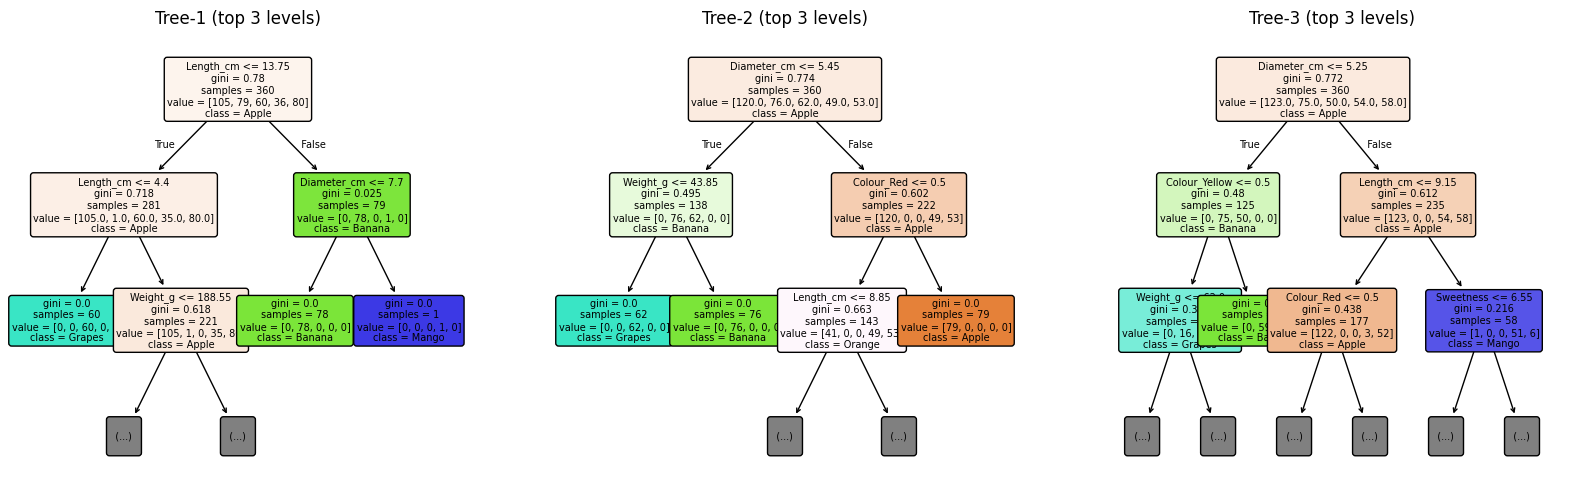

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, i in zip(axes, range(3)):
    plot_tree(trees[i], feature_names=X.columns, class_names=trees[i].classes_, max_depth=2,
              filled=True, rounded=True, fontsize=7, ax=ax)
    ax.set_title(f'Tree-{i + 1} (top 3 levels)')
plt.show()

### A new fruit (the instance)

A yellow, round fruit of about 170 g. Yellow apples and oranges look alike, so the trees may not all agree. Every tree classifies it independently.

In [11]:
instance = pd.DataFrame([{'Weight_g': 170, 'Diameter_cm': 7.9, 'Length_cm': 8.3, 'Sweetness': 6.5, 'Colour': 'Yellow'}])
instance_X = pd.get_dummies(instance, columns=['Colour'], dtype=int).reindex(columns=X.columns, fill_value=0)
instance

,Weight_g,Diameter_cm,Length_cm,Sweetness,Colour
0,170,7.9,8.3,6.5,Yellow


In [12]:
votes = [tree.predict(instance_X)[0] for tree in trees]
for i, v in enumerate(votes, 1):
    print(f"Tree-{i:<3} -> {v}")

Tree-1   -> Orange
Tree-2   -> Apple
Tree-3   -> Orange
Tree-4   -> Apple
Tree-5   -> Apple
Tree-6   -> Orange
Tree-7   -> Orange
Tree-8   -> Apple
Tree-9   -> Apple
Tree-10  -> Orange
Tree-11  -> Orange
Tree-12  -> Orange
Tree-13  -> Apple
Tree-14  -> Orange
Tree-15  -> Apple
Tree-16  -> Orange
Tree-17  -> Apple
Tree-18  -> Apple
Tree-19  -> Apple
Tree-20  -> Apple
Tree-21  -> Apple
Tree-22  -> Apple
Tree-23  -> Apple
Tree-24  -> Apple
Tree-25  -> Apple


In [13]:
tally = Counter(votes)
final_class = tally.most_common(1)[0][0]
print("Majority Voting")
print("---------------------------")
for fruit, n in tally.most_common():
    print(f"{fruit:<8} {n} votes")
print(f"\nFinal class: {final_class}")

Majority Voting
---------------------------
Apple    16 votes
Orange   9 votes

Final class: Apple


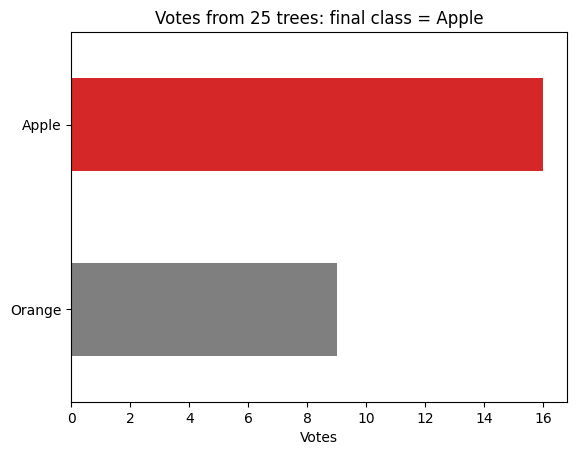

In [14]:
pd.Series(tally).sort_values().plot.barh(color=['tab:red' if f == final_class else 'tab:grey' for f in pd.Series(tally).sort_values().index])
plt.xlabel('Votes'); plt.title(f'Votes from {n_trees} trees: final class = {final_class}')
plt.show()

### The forest on the whole test set

The same majority vote applied to every fruit in the test set, compared with a single decision tree.

In [15]:
all_votes = np.array([tree.predict(X_test) for tree in trees])
forest_pred = np.array([Counter(col).most_common(1)[0][0] for col in all_votes.T])
single_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

print(f"Single decision tree accuracy: {accuracy_score(y_test, single_tree.predict(X_test)):.4f}")
print(f"Average accuracy of the individual trees: {np.mean([accuracy_score(y_test, p) for p in all_votes]):.4f}")
print(f"Hand-built forest (majority vote) accuracy: {accuracy_score(y_test, forest_pred):.4f}")

Single decision tree accuracy: 0.9556
Average accuracy of the individual trees: 0.9218
Hand-built forest (majority vote) accuracy: 0.9444


Each individual tree is trained on only part of the data and a random subset of features, so on its own it is weaker than a full decision tree. Majority voting lifts the forest above the average individual tree. On this dataset the fruits are easy to separate, so a single full tree already does about as well; the benefit of a forest shows most on noisier data, where single trees overfit.

### scikit-learn's RandomForestClassifier

The same idea (bootstrap samples + random feature subsets + majority voting) in one class.

In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
predictions = model.predict(X_test)

In [18]:
print("Actual vs Predicted Fruit")
print("---------------------------")
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})
print(comparison_df)

Actual vs Predicted Fruit
---------------------------
    Actual Predicted
0    Mango     Mango
1    Apple     Apple
2   Grapes    Grapes
3   Orange    Orange
4   Banana    Banana
..     ...       ...
85   Apple     Apple
86  Grapes    Grapes
87  Grapes    Grapes
88  Grapes    Grapes
89  Banana    Banana

[90 rows x 2 columns]


In [19]:
acc = accuracy_score(y_test, predictions)

print("Classification Evaluation Metrics")
print("---------------------------")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions, labels=model.classes_))
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Evaluation Metrics
---------------------------
Accuracy: 0.9667
Confusion Matrix:
[[29  0  0  0  1]
 [ 0 18  0  0  0]
 [ 0  0 14  0  0]
 [ 0  0  0 12  0]
 [ 2  0  0  0 14]]
Classification Report:
              precision    recall  f1-score   support

       Apple       0.94      0.97      0.95        30
      Banana       1.00      1.00      1.00        18
      Grapes       1.00      1.00      1.00        14
       Mango       1.00      1.00      1.00        12
      Orange       0.93      0.88      0.90        16

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



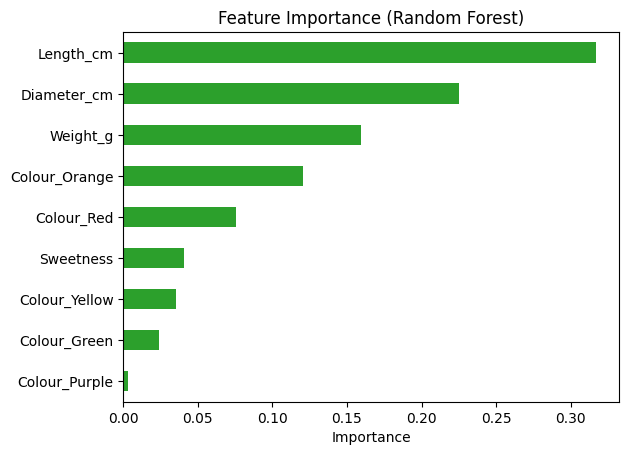

In [20]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importance.plot.barh(color='tab:green')
plt.xlabel('Importance'); plt.title('Feature Importance (Random Forest)')
plt.show()

In [21]:
proba = pd.Series(model.predict_proba(instance_X)[0], index=model.classes_).sort_values(ascending=False)
print("RandomForestClassifier on the new instance")
print("---------------------------")
print((proba * 100).round(1).astype(str) + ' % of trees')
print(f"\nFinal class: {model.predict(instance_X)[0]}")

RandomForestClassifier on the new instance
---------------------------
Apple     72.0 % of trees
Orange    27.0 % of trees
Mango      1.0 % of trees
Grapes     0.0 % of trees
Banana     0.0 % of trees
dtype: object

Final class: Apple


### Answer: which fruit is likely to be taken most often?

**Apple.**

- It is the most common fruit in the basket (150 of 450, 33%). Because each tree's sample is drawn at random from the basket, apples are also the fruit picked most often into every sample (about 121 of the 360 fruits per sample, on average).
- When the trees classify the new instance, some say Orange, but most say **Apple (16 of 25 trees)**. Majority voting therefore gives **Apple** as the final class, just like the figure (Tree-1: Apple, Tree-2: Apple, Tree-n: Banana → final class Apple).
- scikit-learn's `RandomForestClassifier` (100 trees) agrees: 72% of its trees vote Apple.